# Preperation

In [1]:
# imports
import os
import csv
import math
import copy
import pickle
import pandas as pd
from tqdm.notebook import tqdm

from rdkit import Chem,DataStructs
from rdkit.Chem import AllChem,Draw

import numpy as np
import scipy.stats as st
from scipy.spatial import distance,ConvexHull

from sklearn import preprocessing
from sklearn.decomposition import PCA,KernelPCA

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import matplotlib.lines as mlines

from rdkit.Chem import MACCSkeys,AllChem,Draw
# from mordred import Calculator, descriptors ## note this was manually fixed by replacing instances of "np.float" with "float"

from working_scripts.GeneralFunctions import RDKitCarefulSanitize
from padelpy import from_smiles

# import umap ## had to update umap to remove "ensure_all_finite" when calling "check_array"
# from FastEuclid import fasteuclid as EuclidMat, fastclasscomparison as ClassComparison, fastradiuscomparison as RadiusComparison

In [2]:
def standardscalar(X):
    scaler = preprocessing.StandardScaler()
    scaler.fit(X)
    return scaler.transform(X)

def density_map_data(x,y,x_range,y_range):
    xmin,xmax = x_range
    ymin,ymax = y_range
    xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values = np.vstack([np.array(x), np.array(y)])
    kernel = st.gaussian_kde(values)
    f = np.reshape(kernel(positions).T, xx.shape)
    return xx,yy,f

In [ ]:
Descriptor_names = {
    'MolWt' :'molecular weight\n(Da)',
    'molecular complexity' : "Böttcher’s molecular\ncomplexity",
    'BertzCT' : "Bertz’s complexity\nindex", 
    'MolLogP' : 'predicted\nLog $\it{P}$',
    'apol' : 'atom polarizability\n($Å^3$)',
    'bpol' : 'bond polarizability\n($Å^3$)',
    'proportion O' : 'proportion\noxygen',
    'proportion N' : 'proportion\nnitrogen',
    'proportion S' : 'proportion\nsulfur',
    'LabuteASA' : 'Labute accessible\nsurface area ($Å^2$)',
    'RotRatio' : 'rotatable\nbond ratio',
    'proportion aromatic' : 'proportion\naromatic',
    'proportion ring' : 'proportion\nring',
    'TPSA' : 'topological polar\nsurface area ($Å^2$)',
    'NumHAcceptors' : 'number H-bond\nacceptors',
    'NumHDonors' : 'number H-bond\ndonors'
}

## Loading Data

In [4]:
with open('output_data/TotalDataset.pk1','rb') as handle:   
    datasets = pickle.load(handle)
NPBool = [bool(i) for i in datasets['NP info']]

Natural = {k:[i for i,b in zip(v,NPBool) if b] for k,v in datasets.items()}
Synthetic = {k:[i for i,b in zip(v,NPBool) if not b] for k,v in datasets.items()}

# Publication Figures

In [5]:
cm = 1/2.54
plt.rcParams['font.family'] = "Times New Roman"
plt.rcParams['font.size'] = 12

### Cover image

In [6]:
plt.rcParams['font.size'] = 12

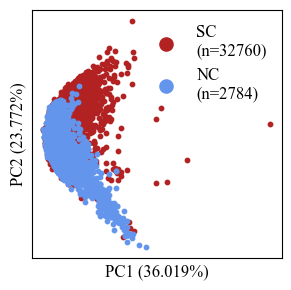

In [168]:
wanted_descs = ['MolWt'
                ,'LabuteASA'
                ,'molecular complexity'
                ,'BertzCT'
                ,'apol',
                'bpol']+[
                        'NumHAcceptors'
                        ,'NumHDonors'
                         ,'TPSA'
                         ,'MolLogP'
                         ]+['proportion O','proportion N','proportion S',]+['RotRatio','proportion ring','proportion aromatic']
NP_pre = [[v for k,v in i.items() if k in wanted_descs] for i in Natural['descriptors'] if i]
SN_pre = [[v for k,v in i.items() if k in wanted_descs] for i in Synthetic['descriptors'] if i]

ScaleData = standardscalar([[v for k,v in i.items() if k in wanted_descs] for i in datasets['descriptors']])
pca = PCA(n_components=2)
pca.fit(ScaleData)
PCAcoeff = pca.components_.T

fig,ax = plt.subplots(1,1,figsize=(8.2*cm, 8.2*cm))
point_size = 10
ax.set_xlabel('PC1 ('+str(round(pca.explained_variance_ratio_[0]*100,3))+'%)')
ax.set_ylabel('PC2 ('+str(round(pca.explained_variance_ratio_[1]*100,3))+'%)')
ax.set_xticks([])
ax.set_yticks([])
ax.scatter(Synthetic['PC1'],Synthetic['PC2'],label='SC\n(n='+str(len(SN_pre))+')',color='firebrick',s=point_size)
ax.scatter(Natural['PC1'],Natural['PC2'],label='NC\n(n='+str(len(NP_pre))+')',color='cornflowerblue',s=point_size)
ax.legend(loc='upper right',facecolor='none',edgecolor='none',markerscale=3)
Xaxis = ax.get_xlim()
Yaxis = ax.get_ylim()
fig.savefig('Publication Images/'+'CoverImage.png',dpi=1000)

### Figure 1

In [8]:
CSDBool = [i=='Cambridge Structural Database' or 'Cambridge Structural Database' in i for i in datasets['database']]
CSDNPBool = [i and j for i,j in zip(CSDBool,NPBool)]
PDBBool = [i=='Protein Data Bank' or 'Protein Data Bank' in i for i in datasets['database']]
PDBNPBool = [i and j for i,j in zip(PDBBool,NPBool)]
SDRBool = [i=='Siderite' or 'Siderite' in i for i in datasets['database']]

print('total:',len(datasets['database']),'Natural:',sum(NPBool),'Synthetic:',len(datasets['database'])-sum(NPBool),'\n')
print('CSD:',sum(CSDBool),'num NP:',sum(CSDNPBool),'Syn (%):',100-(sum(CSDNPBool)/sum(CSDBool))*100)
print('PDB:',sum(PDBBool),'num NP:',sum(PDBNPBool),'Syn (%):',100-(sum(PDBNPBool)/sum(PDBBool))*100)
print('SDR:',sum(SDRBool),'num NP:',sum(SDRBool),'Syn (%):',0)
print('CSD (%) of syn:',(sum(CSDBool)-sum(CSDNPBool))/(len(datasets['database'])-sum(NPBool))*100)

total: 35544 Natural: 2784 Synthetic: 32760 

CSD: 31357 num NP: 797 Syn (%): 97.45830277131103
PDB: 3288 num NP: 1087 Syn (%): 66.9403892944039
SDR: 918 num NP: 918 Syn (%): 0
CSD (%) of syn: 93.28449328449328


### Figure 2

In [170]:
plt.rcParams['font.size'] = 12

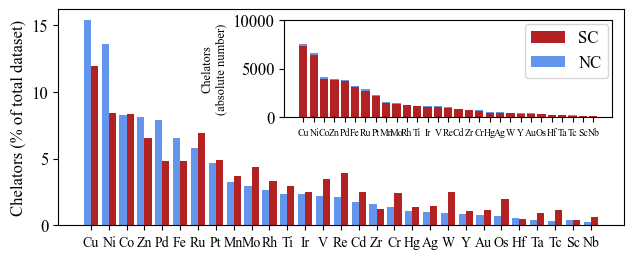

In [171]:
MetalCounts = {}

TotMet,NPMet,SNMet = {},{},{}
[TotMet.update({m:TotMet[m]+1}) if m in TotMet else TotMet.update({m:1}) for d,ms in  zip(datasets['database'],datasets['metal']) if d=='Cambridge Structural Database' for m in set(ms.split(';'))]
[NPMet.update({m:NPMet[m]+1}) if m in NPMet else NPMet.update({m:1}) for d,ms in  zip(Natural['database'],Natural['metal']) if d=='Cambridge Structural Database' for m in set(ms.split(';'))]
[SNMet.update({m:SNMet[m]+1}) if m in SNMet else SNMet.update({m:1}) for d,ms in  zip(Synthetic['database'],Synthetic['metal']) if d=='Cambridge Structural Database' for m in set(ms.split(';'))]
KeyOrder = [x for x, _ in sorted(TotMet.items(), key=lambda item: item[1],reverse=True)]

Cs = [(0.3,0.3,0.3)]*len(KeyOrder)

width = 0.4
X = np.arange(len(KeyOrder))
SNMetStand = {k:(v*100/sum(NPMet.values())) for k,v in NPMet.items()}
NPMetStand = {k:(v*100/sum(SNMet.values())) for k,v in SNMet.items()}

fig, ax = plt.subplots(1,1,figsize=(16.5*cm, 7*cm))
ax.bar(x = X+(width/2),height = [SNMetStand[k] for k in KeyOrder],color='firebrick',label='SC',width=width)
ax.bar(x = X-(width/2),height = [NPMetStand[k] for k in KeyOrder],color='cornflowerblue',label='NC',width=width)
ax.legend(fontsize=12,bbox_to_anchor=(0,0,.987,.97),)
ax.set_xticks(X, KeyOrder,fontsize=10)
ax.set_ylabel('Chelators (% of total dataset)', fontsize=12)
fig.tight_layout()

ax2 = ax.inset_axes([0.4,0.5,0.58,0.45])
bottom = [0]*len(Cs)
for label,heighs,clr in zip(('Synthetic','Natural'),(SNMet,NPMet),('firebrick','cornflowerblue')):
    ax2.bar(x = X,height = [heighs[k] for k in KeyOrder],color=clr,bottom=bottom)
    ax2.set_xticks(X, KeyOrder,fontsize=7)
    bottom = [heighs[k]+b for k,b in zip(KeyOrder,bottom)]
ax2.set_ylabel('Chelators\n(absolute number)', fontsize=9)
ax2.set_yticks([0,5000,10000])
fig.tight_layout()
fig.savefig('Publication Images/'+'Figure2.png',dpi=1000)

### Figure 3

In [172]:
plt.rcParams['font.size'] = 8

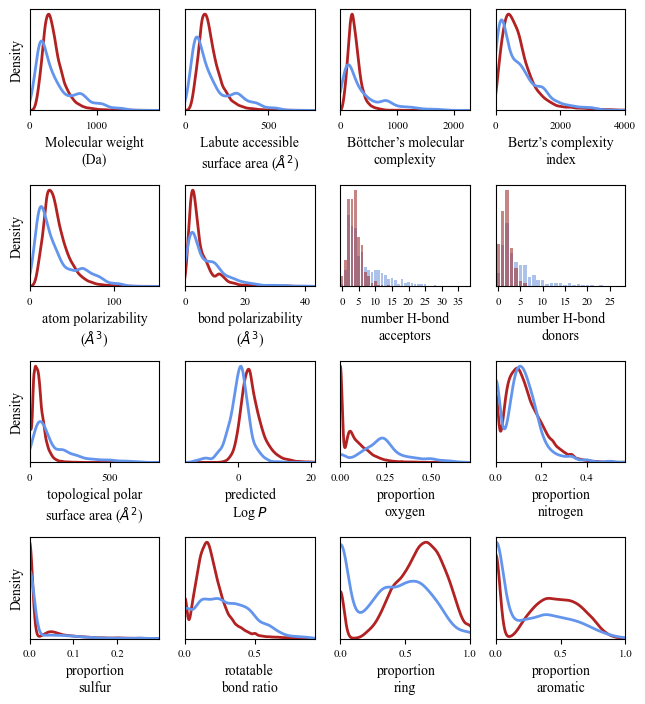

In [173]:
wanted_descs = ['MolWt','LabuteASA','molecular complexity','BertzCT','apol','bpol']+['NumHAcceptors','NumHDonors','TPSA','MolLogP']+['proportion O','proportion N','proportion S',]+['RotRatio','proportion ring','proportion aromatic']
cols = 4
Nstdv = 5
n = math.ceil(len(wanted_descs)/cols)
fig,axs = plt.subplots(n,cols,figsize=(16.51*cm,18*cm))
for i in range((cols*n)-len(wanted_descs)):
    axs.flatten()[-(i+1)].set_visible(False)
for ax in axs:
    ax[0].set_ylabel('Density',fontsize=10)

for ax1,desc in zip(axs.flatten(),wanted_descs):
    for ax in [ax1]:
        ax.set_xlabel(Descriptor_names[desc],fontsize=10)
        ax.set_yticks([])
        NP_data = [i[desc] for i in Natural['descriptors']]
        SN_data = [i[desc] for i in Synthetic['descriptors']]
        SNave,NPave = np.average(SN_data),np.average(NP_data)
        SNstd,NPstd = np.std(SN_data),np.std(NP_data)
        if desc != 'MolLogP':
            Bottom = 0
        else:
            Bottom = max([min(NP_data+SN_data),min([SNave-Nstdv*SNstd,NPave-Nstdv*NPstd])])
        Top = min([max(NP_data+SN_data),max([SNave+Nstdv*SNstd,NPave+Nstdv*NPstd])])
        if 'number' in Descriptor_names[desc]: ## H-bond data and Max E-state index
            increments = 5
            alpha = .6
            ticks = list(range(0,(math.ceil(Top)//increments+1)*increments,increments))
            NP_dt,SN_dt = [([sum([j == i for j in d])/len(d) for i in set(d)],list(set(d))) for d in [NP_data,SN_data]]
            sns.barplot(x=NP_dt[1],y=NP_dt[0],color='cornflowerblue', label='',ax=ax)
            for bar in ax.containers[0]:
                bar.set_alpha(alpha)
            sns.barplot(x=SN_dt[1],y=SN_dt[0],color='firebrick', label='',ax=ax)
            for bar in ax.containers[1]:
                bar.set_alpha(alpha)
            ax.set_xticks(ticks,labels=ticks,fontsize=8)       

        else:
            vs = np.linspace(Bottom,Top,1000)
            kde = st.gaussian_kde(SN_data)
            ax.plot(vs,kde(vs),c='firebrick',linewidth=2)

            kde = st.gaussian_kde(NP_data)
            ax.plot(vs,kde(vs),c='cornflowerblue',linewidth=2)
            ax.set_xlim(Bottom,Top)
            ax.set_ylim(0,ax.get_ylim()[1])
    # fig2.savefig("IC24 images/"+desc+" dist.png")
fig.tight_layout()
fig.savefig('Publication Images/'+'Figure3.png',dpi=1000)

### Figure 4

In [174]:
plt.rcParams['font.size'] = 10

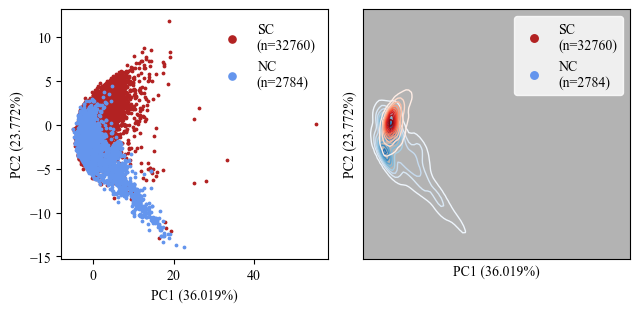

In [175]:
fig, (ax,ax2) = plt.subplots(1,2,figsize=(16.51*cm, 8.2*cm))
point_size = 3
ax.set_xlabel('PC1 ('+str(round(pca.explained_variance_ratio_[0]*100,3))+'%)')
ax.set_ylabel('PC2 ('+str(round(pca.explained_variance_ratio_[1]*100,3))+'%)')
# ax.set_xticks([])
# ax.set_yticks([])
ax.scatter(Synthetic['PC1'],Synthetic['PC2'],label='SC\n(n='+str(len(SN_pre))+')',color='firebrick',s=point_size)
ax.scatter(Natural['PC1'],Natural['PC2'],label='NC\n(n='+str(len(NP_pre))+')',color='cornflowerblue',s=point_size)
ax.legend(loc='upper right',facecolor='none',edgecolor='none',markerscale=3)
Xaxis = ax.get_xlim()
Yaxis = ax.get_ylim()


xlims = Xaxis; ylims = Yaxis
NPkde = density_map_data(Natural['PC1'],Natural['PC2'],xlims,ylims)
SNkde = density_map_data(Synthetic['PC1'],Synthetic['PC2'],xlims,ylims)
vlims = [min([k for i in [NPkde[2],SNkde[2]] for j in i for k in j]),max([k for i in [NPkde[2],SNkde[2]] for j in i for k in j])]
steps= 10
x,y,z = NPkde
m = np.amax(z)
levels = [((m/steps)*(i+0.5)) for i in range(steps)]
ax2.contour(x,y,z,levels,cmap='Blues',vmin=0,vmax=m,linewidths=1)
x,y,z = SNkde
m = np.amax(z)
levels = [((m/steps)*(i+0.5)) for i in range(steps)]
ax2.contour(x,y,z,levels,cmap='Reds',vmin=0,vmax=m,linewidths=1)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_ylim(Xaxis)
ax2.set_ylim(Yaxis)
ax2.set_xlabel('PC1 ('+str(round(pca.explained_variance_ratio_[0]*100,3))+'%)')
ax2.set_ylabel('PC2 ('+str(round(pca.explained_variance_ratio_[1]*100,3))+'%)')
c = mlines.Line2D([], [], color='firebrick', marker='.', ls='', label='SC\n(n='+str(len(SN_pre))+')')
s = mlines.Line2D([], [], color='cornflowerblue', marker='.', ls='', label='NC\n(n='+str(len(NP_pre))+')')
ax2.legend(handles=[c,s],loc='upper right',facecolor='white',edgecolor='white',markerscale=1.8)
ax2.set_facecolor([0.7]*3)
fig.tight_layout()
fig.savefig('Publication Images/'+'Figure4.png',dpi=1000)

In [176]:
Nat = list(zip(*[Natural['PC1'],Natural['PC2']]))
Syn = list(zip(*[Synthetic['PC1'],Synthetic['PC2']]))
NatAve = (sum(Natural['PC1'])/len(Natural['PC1']),sum(Natural['PC2'])/len(Natural['PC2']))
SynAve = (sum(Synthetic['PC1'])/len(Synthetic['PC1']),sum(Synthetic['PC2'])/len(Synthetic['PC2']))

percentage = 0.99

NatDist = distance.cdist(Nat,[NatAve],metric='euclidean').T[0]
NatIdx = sorted(list(range(len(Nat))), key=lambda x: NatDist[x])[:int(round(len(Nat)*percentage,0))-1]

SynDist = distance.cdist(Syn,[SynAve],metric='euclidean').T[0]
SynIdx = sorted(list(range(len(Syn))), key=lambda x: SynDist[x])[:int(round(len(Syn)*percentage,0))-1]

print('Nat area:',ConvexHull([Nat[i] for i in NatIdx]).volume)
print('Syn area:',ConvexHull([Syn[i] for i in SynIdx]).volume)

Nat area: 181.82665102821284
Syn area: 114.22449771579653


### Figure 5

In [177]:
plt.rcParams['font.size'] = 10

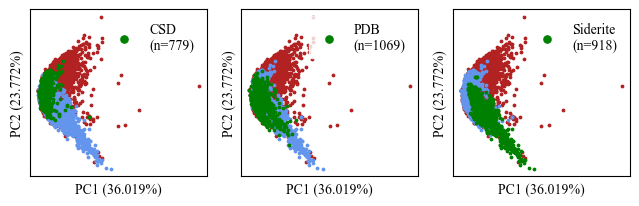

In [178]:
ds_names = {'Cambridge Structural Database':'CSD','Protein Data Bank':'PDB','Siderite':'Siderite'}

fig, axs = plt.subplots(1,3,figsize=(16.51*cm,5.5*cm))
for focus,ax in zip(ds_names.keys(),list(axs)):
    d1 = ([i for i,d in zip(Natural['PC1'],Natural['database']) if d!=focus],[i for i,d in zip(Natural['PC2'],Natural['database']) if d!=focus])
    d2 = ([i for i,d in zip(Natural['PC1'],Natural['database']) if d==focus],[i for i,d in zip(Natural['PC2'],Natural['database']) if d==focus])

    point_size = 3
    ax.set_xlabel('PC1 ('+str(round(pca.explained_variance_ratio_[0]*100,3))+'%)')
    ax.set_ylabel('PC2 ('+str(round(pca.explained_variance_ratio_[1]*100,3))+'%)')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.scatter([Synthetic['PC1']],Synthetic['PC2'],color='firebrick',s=point_size)
    ax.scatter(d1[0],d1[1],color='cornflowerblue',s=point_size)
    ax.scatter(d2[0],d2[1],label=ds_names[focus]+'\n(n='+str(len([i for i in Natural['database'] if i==focus]))+')',color='green',s=point_size)
    ax.legend(loc='upper right',facecolor='white',edgecolor='white',markerscale=3)
    Xaxis = ax.get_xlim()
    Yaxis = ax.get_ylim()
fig.tight_layout()
fig.savefig('Publication Images/'+'Figure5.png',dpi=1000)

In [179]:
plt.rcParams['font.size'] = 8

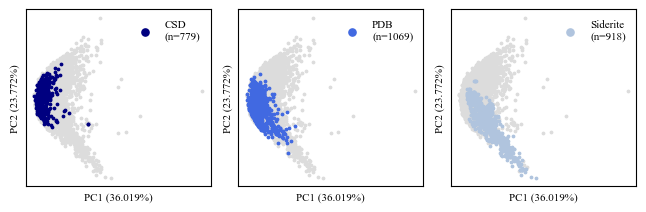

In [180]:
ds_names = {'Cambridge Structural Database':'CSD','Protein Data Bank':'PDB','Siderite':'Siderite'}
ds_colors = {'Cambridge Structural Database':'navy','Protein Data Bank':'royalblue','Siderite':'lightsteelblue'}
fig, axs = plt.subplots(1,3,figsize=(16.51*cm,5.5*cm))
for focus,ax in zip(ds_names.keys(),list(axs)):
    d1 = ([i for i,d in zip(Natural['PC1'],Natural['database']) if d!=focus],[i for i,d in zip(Natural['PC2'],Natural['database']) if d!=focus])
    d2 = ([i for i,d in zip(Natural['PC1'],Natural['database']) if d==focus],[i for i,d in zip(Natural['PC2'],Natural['database']) if d==focus])

    point_size = 3
    ax.set_xlabel('PC1 ('+str(round(pca.explained_variance_ratio_[0]*100,3))+'%)')
    ax.set_ylabel('PC2 ('+str(round(pca.explained_variance_ratio_[1]*100,3))+'%)')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.scatter([Synthetic['PC1']],Synthetic['PC2'],color='gainsboro',s=point_size)
    ax.scatter(d1[0],d1[1],color='gainsboro',s=point_size)
    ax.scatter(d2[0],d2[1],label=ds_names[focus]+'\n(n='+str(len([i for i in Natural['database'] if i==focus]))+')',color=ds_colors[focus],s=point_size)
    ax.legend(loc='upper right',facecolor='white',edgecolor='white',markerscale=3)
    Xaxis = ax.get_xlim()
    Yaxis = ax.get_ylim()
fig.tight_layout()
fig.savefig('Publication Images/'+'Figure_alt5A.png',dpi=1000)

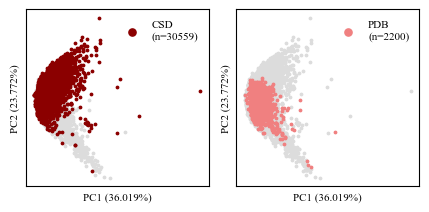

In [181]:
ds_names = {'Cambridge Structural Database':'CSD','Protein Data Bank':'PDB'}
ds_colors = {'Cambridge Structural Database':'darkred','Protein Data Bank':'lightcoral'}
fig, axs = plt.subplots(1,2,figsize=(16.51*cm*2/3,5.5*cm))
for focus,ax in zip(ds_names.keys(),list(axs)):
    d1 = ([i for i,d in zip(Synthetic['PC1'],Synthetic['database']) if d!=focus],[i for i,d in zip(Synthetic['PC2'],Synthetic['database']) if d!=focus])
    d2 = ([i for i,d in zip(Synthetic['PC1'],Synthetic['database']) if d==focus],[i for i,d in zip(Synthetic['PC2'],Synthetic['database']) if d==focus])

    point_size = 3
    ax.set_xlabel('PC1 ('+str(round(pca.explained_variance_ratio_[0]*100,3))+'%)')
    ax.set_ylabel('PC2 ('+str(round(pca.explained_variance_ratio_[1]*100,3))+'%)')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.scatter([Natural['PC1']],Natural['PC2'],color='gainsboro',s=point_size)
    ax.scatter(d1[0],d1[1],color='gainsboro',s=point_size)
    ax.scatter(d2[0],d2[1],label=ds_names[focus]+'\n(n='+str(len([i for i in Synthetic['database'] if i==focus]))+')',color=ds_colors[focus],s=point_size)
    ax.legend(loc='upper right',facecolor='white',edgecolor='white',markerscale=3)
    Xaxis = ax.get_xlim()
    Yaxis = ax.get_ylim()
fig.tight_layout()
fig.savefig('Publication Images/'+'Figure_alt5B.png',dpi=1000)

### Figure 6

In [182]:
ScaleData = standardscalar([[v for k,v in i.items() if k in wanted_descs] for i in datasets['descriptors']])

NPPairDists = distance.squareform(distance.pdist([i for i,j in zip(ScaleData,NPBool) if j],metric='euclidean'))
SNPairDists = distance.squareform(distance.pdist([i for i,j in zip(ScaleData,NPBool) if not j],metric='euclidean'))

NPAvePairDists = [sum(i)/len(i) for i in NPPairDists]
SNAvePairDists = [sum(i)/len(i) for i in SNPairDists]

NpAvePairD = NPPairDists.sum()/(len(Natural['PC1'])**2-len(Natural['PC1']))
SNAvePairD = SNPairDists.sum()/(len(Synthetic['PC1'])**2-len(Synthetic['PC1']))
print('Average distance between points','NP:',round(NpAvePairD,2),'SN',round(SNAvePairD,2))

NPAveNN = sum([min(i) for i in NPPairDists[~np.eye(NPPairDists.shape[0],dtype=bool)].reshape(NPPairDists.shape[0],-1)])/len(Natural['PC1'])
SNAveNN = sum([min(i) for i in SNPairDists[~np.eye(SNPairDists.shape[0],dtype=bool)].reshape(SNPairDists.shape[0],-1)])/len(Natural['PC1'])
print('Average nearest neighbour\t','NP:',round(NPAveNN,2),'SN',round(SNAveNN,2))

NP_SNPairDists = distance.cdist([i for i,j in zip(ScaleData,NPBool) if j],[i for i,j in zip(ScaleData,NPBool) if not j],metric='euclidean')
NP_SNAveDist = NP_SNPairDists.sum()/NP_SNPairDists.size
print('Average SN-NP distance:',round(NP_SNAveDist,2))

Average distance between points NP: 7.61 SN 4.58
Average nearest neighbour	 NP: 0.63 SN 6.68
Average SN-NP distance: 7.0


In [183]:
plt.rcParams['font.size'] = 12

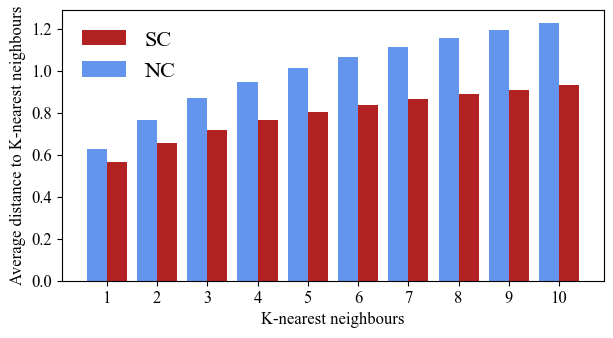

In [184]:
NNmax = 10
NPAveSorted = np.sort(NPPairDists,axis=0)[1:NNmax+1,:]
SNAveSorted = np.sort(SNPairDists,axis=0)[1:NNmax+1,:]
KeyOrder, NPKNNDist,SNKNNDist = [],[],[]
for i in range(NNmax):
    NPKNNDist.append(NPAveSorted[:i+1,:].sum()/(NPAveSorted.shape[1]*(i+1)))
    SNKNNDist.append(SNAveSorted[:i+1,:].sum()/(SNAveSorted.shape[1]*(i+1)))
    KeyOrder.append(str(i+1))
X = np.arange(len(KeyOrder))
fig, ax = plt.subplots(1,1,figsize=(16*cm, 9*cm))
width = 0.4
ax.bar(x = X+(width/2),height = SNKNNDist,color='firebrick',label='SC',width=width)
ax.bar(x = X-(width/2),height = NPKNNDist,color='cornflowerblue',label='NC',width=width)
ax.legend(fontsize=16,facecolor='none',edgecolor='none')
ax.set_xticks(X, KeyOrder)
ax.set_xlabel('K-nearest neighbours', fontsize=12)
ax.set_ylabel('Average distance to K-nearest neighbours', fontsize=12)
fig.tight_layout()
fig.savefig('Publication Images/'+'Figure6.png',dpi=1000)

### Figure 7

In [185]:
plt.rcParams['font.size'] = 10

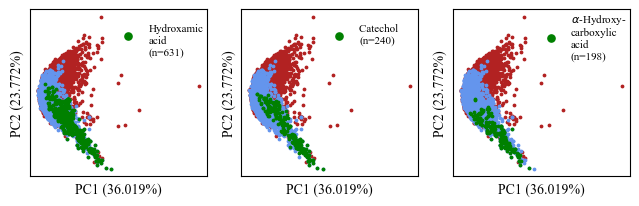

In [186]:
with open('input_data\Siderite_2025_paper_tableS2.csv','r') as f:
    Ls = [i for i in csv.reader(f, delimiter=',', quotechar='"')]
    Ls = [(i[1],i[19].replace('"','')) for i in Ls[1:]]

BindingGroup = [[bg for m,bg in Ls if m==n][0].split('/') for n,s in zip(Natural['name'],Natural['database']) if s=='Siderite']
BGs = ['Hydroxamate','Catecholate','Alpha-Hydroxycarboxylate']
BG_names = {'Hydroxamate': '\nHydroxamic\nacid'+'\n(n='+str(len([i for i in BindingGroup if 'Hydroxamate' in i]))+')',
            'Catecholate':'\nCatechol      '+'\n(n='+str(len([i for i in BindingGroup if 'Catecholate' in i]))+')\n',
            'Alpha-Hydroxycarboxylate':r'$\alpha$-Hydroxy'+"-\ncarboxylic\nacid"+'\n(n='+str(len([i for i in BindingGroup if 'Alpha-Hydroxycarboxylate' in i]))+')'}

SideritePCA = [(i,j) for i,j,d in zip(Natural['PC1'],Natural['PC2'],Natural['database']) if d == 'Siderite']
fig, axs = plt.subplots(1,len(BGs),figsize=(16.51*cm,5.5*cm))
for bg,ax in zip(BGs,list(axs)):
    d1 = ([i[0] for i,d in zip(SideritePCA,BindingGroup) if bg in d],[i[1] for i,d in zip(SideritePCA,BindingGroup) if bg in d])
    point_size = 3
    ax.set_xlabel('PC1 ('+str(round(pca.explained_variance_ratio_[0]*100,3))+'%)')
    ax.set_ylabel('PC2 ('+str(round(pca.explained_variance_ratio_[1]*100,3))+'%)')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.scatter([Synthetic['PC1']],Synthetic['PC2'],color='firebrick',s=point_size)
    ax.scatter([Natural['PC1']],Natural['PC2'],color='cornflowerblue',s=point_size)
    ax.scatter(d1[0],d1[1],label=BG_names[bg],color='green',s=point_size)
    ax.legend(loc='upper right',facecolor='white',edgecolor='white',markerscale=3,bbox_to_anchor=(0,0,.95,.95), borderpad=-1,fontsize=8)
    Xaxis = ax.get_xlim()
    Yaxis = ax.get_ylim()
fig.tight_layout()
fig.savefig('Publication Images/'+'Figure7.png',dpi=1000)

### Figure 8

In [187]:
plt.rcParams['font.size'] = 10

80


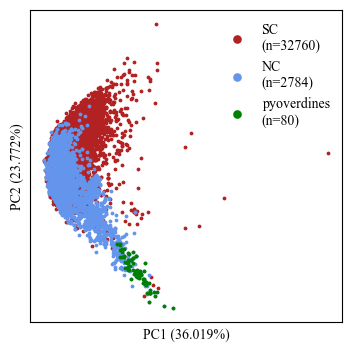

In [188]:
Ns = [n for n,i in enumerate(Natural['name']) if i and 'pyoverdine' in i.lower()]
print(len(Ns))
fig, ax = plt.subplots(1,1,figsize=(9.2*cm, 9.2*cm))
point_size = 3
ax.set_xlabel('PC1 ('+str(round(pca.explained_variance_ratio_[0]*100,3))+'%)')
ax.set_ylabel('PC2 ('+str(round(pca.explained_variance_ratio_[1]*100,3))+'%)')
ax.set_xticks([])
ax.set_yticks([])
ax.scatter(Synthetic['PC1'],Synthetic['PC2'],label='SC\n(n='+str(len(SN_pre))+')',color='firebrick',s=point_size)
ax.scatter(Natural['PC1'],Natural['PC2'],label='NC\n(n='+str(len(NP_pre))+')',color='cornflowerblue',s=point_size)
ax.scatter([Natural['PC1'][i] for i in Ns],[Natural['PC2'][i] for i in Ns],label='pyoverdines\n(n='+str(len(Ns))+')',color='green',s=point_size)
ax.legend(loc='upper right',facecolor='white',edgecolor='white',markerscale=3)
Xaxis = ax.get_xlim()
Yaxis = ax.get_ylim()
fig.tight_layout()
fig.savefig('Publication Images/'+'Figure8.png',dpi=1000)

### Figure 9

In [189]:
plt.rcParams['font.size'] = 10

['C[C@H](NC(=O)[C@H](NC(=O)[C@H](CO)NC(=O)CNC(=O)[C@@H]1CCN=C(C(CO)NC(=O)[C@@H]2CCNC3C(NC(=O)CC(O)C(N)=O)=Cc4cc(O)c(O)cc4N32)N1)C(O)C(=O)O)C(=O)NCC(=O)N[C@H](C)C(=O)NCC(=O)N[C@H]1CCCN(O)C1=O']
['NCCCC[C@@H]1NC(=O)[C@H](CCCN(O)C=O)NC(=O)[C@@H](NC(=O)C(CO)NC(=O)C(CO)NC(=O)[C@H](CCCN(O)C=O)NC(=O)[C@H](CO)NC(=O)[C@H](CO)NC(=O)C2CCNC3C(NC(=O)CCC(=O)C(=O)O)=Cc4cc(O)c(O)cc4N23)CCCCNC(=O)[C@@H](CO)NC1=O']
['CC(=O)N(O)CCC[C@H](NC(=O)[C@H](CCN)NC(=O)[C@@H](NC(=O)[C@H](CCCN)NC(=O)[C@@H](C)NC(=O)C1CCNC2C(NC(=O)CCC(N)=O)=Cc3cc(O)c(O)cc3N12)C(O)C(=O)O)C(=O)N[C@@H](CCCCN)C(=O)O']


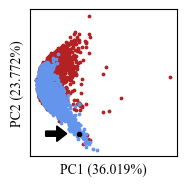

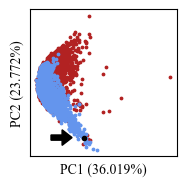

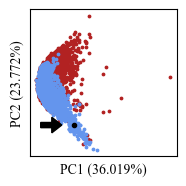

In [190]:
for N in ['Pyoverdine 10.1','Pyoverdine 9.10','Pyoverdine 6.8']:
    Ns = [j for i,j in zip(Natural['name'],Natural['smiles']) if i and N.lower() == i.lower()]
    print(Ns)
    Ns = [n for n,i in enumerate(Natural['name']) if i and N.lower() == i.lower()]
    fig, ax = plt.subplots(1,1,figsize=(5*cm, 5*cm))
    point_size = 3
    ax.set_xlabel('PC1 ('+str(round(pca.explained_variance_ratio_[0]*100,3))+'%)')
    ax.set_ylabel('PC2 ('+str(round(pca.explained_variance_ratio_[1]*100,3))+'%)')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.scatter(Synthetic['PC1'],Synthetic['PC2'],label='non-natural chelators\n(n='+str(len(SN_pre))+')',color='firebrick',s=point_size)
    ax.scatter(Natural['PC1'],Natural['PC2'],label='natural product\nchelators\n(n='+str(len(NP_pre))+')',color='cornflowerblue',s=point_size)
    ax.scatter([Natural['PC1'][i] for i in Ns],[Natural['PC2'][i] for i in Ns],color='black',s=point_size*3)
    ax.arrow([Natural['PC1'][i] for i in Ns][0]-15,[Natural['PC2'][i] for i in Ns][0],5,0,width=1,color='black',shape='full',head_starts_at_zero=False)
    # ax.scatter([Natural['PC1'][i] for i in Ns],[Natural['PC2'][i] for i in Ns],facecolors='none',edgecolors='black',s=point_size*50,marker='o',)
    # ax.legend(loc='upper right')
    Xaxis = ax.get_xlim()
    Yaxis = ax.get_ylim()
    fig.tight_layout()
    fig.savefig('Publication Images/'+'Figure9-'+N+'.png',dpi=1000)

### Figure 10

In [191]:
plt.rcParams['font.size'] = 10

In [192]:
Synthetic['molecule'] = [Chem.MolFromSmiles(s,sanitize=True) for s in Synthetic['smiles']]
Natural['molecule'] = [Chem.MolFromSmiles(s,sanitize=True) for s in Natural['smiles']]

[14:18:10] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 9 10 11 12 13 14
[14:18:10] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
[14:18:11] Can't kekulize mol.  Unkekulized atoms: 3 4 6
[14:18:11] Can't kekulize mol.  Unkekulized atoms: 4 5 6 11 25
[14:18:11] Can't kekulize mol.  Unkekulized atoms: 4 5 11 12 13 14 15 16 17
[14:18:12] Can't kekulize mol.  Unkekulized atoms: 10 12 13
[14:18:13] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 9 12 13 14 18 19
[14:18:13] Can't kekulize mol.  Unkekulized atoms: 7 8 12 13 14 15 16 17 18
[14:18:14] Can't kekulize mol.  Unkekulized atoms: 6 7 10
[14:18:16] Can't kekulize mol.  Unkekulized atoms: 4 5 10 15 20
[14:18:16] Can't kekulize mol.  Unkekulized atoms: 2 4 6 8 10
[14:18:16] Can't kekulize mol.  Unkekulized atoms: 4 5 6 13 26


619


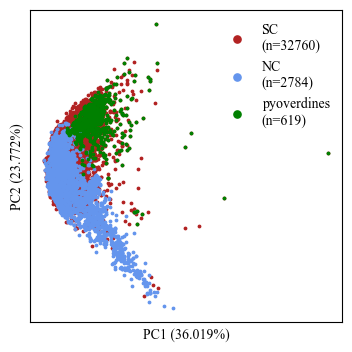

In [193]:
PorphyrinDefs = [
    '[#7;r5]1-[#6;r5]-[#6]=[#6;r5]-[#7;r5]=[#6;r5]-[#6]=[#6;r5]-[#7;r5]-[#6;r5]=[#6]-[#6;r5]=[#7;r5]-[#6;r5]=[#6]-[#6;r5]-1',
    '[#7;r5]1-[#6;r5]=[#6]-[#6;r5]=[#7;r5]-[#6;r5]=[#6]-[#6;r5]=[#7;r5]-[#6;r5]=[#6]-[#6;r5]=[#7;r5]-[#6;r5]=[#6]-[#6;r5]=1',
    '[#7;r5]1-[#6;r5]=[#6]-[#6;r5]=[#7;r5]-[#6;r5]=[#6]-[#6;r5]=[#7;r5]-[#6;r5]=[#6]-[#6;r5]=[#7;r5]-[#6;r5]-[#6;r5]-1',
    '[#7;r5]1:[#6;r5]:[#6]:[#6;r5]:[#7;r5]:[#6;r5]:[#6]:[#6;r5]:[#7;r5]:[#6;r5]:[#6]:[#6;r5]:[#7;r5]:[#6;r5]:[#6]:[#6;r5]:1',


    '[#7;r5]1-[#6;r5]-[#7]=[#6;r5]-[#7;r5]=[#6;r5]-[#7]=[#6;r5]-[#7;r5]-[#6;r5]=[#7]-[#6;r5]=[#7;r5]-[#6;r5]=[#7]-[#6;r5]-1',
    '[#7;r5]1-[#6;r5]=[#7]-[#6;r5]=[#7;r5]-[#6;r5]=[#7]-[#6;r5]=[#7;r5]-[#6;r5]=[#7]-[#6;r5]=[#7;r5]-[#6;r5]=[#7]-[#6;r5]=1',
    '[#7;r5]1-[#6;r5]=[#7]-[#6;r5]=[#7;r5]-[#6;r5]=[#7]-[#6;r5]=[#7;r5]-[#6;r5]=[#7]-[#6;r5]=[#7;r5]-[#6;r5]-[#6;r5]-1',
    '[#7;r5]1:[#6;r5]:[#7]:[#6;r5]:[#7;r5]:[#6;r5]:[#7]:[#6;r5]:[#7;r5]:[#6;r5]:[#7]:[#6;r5]:[#7;r5]:[#6;r5]:[#7]:[#6;r5]:1',
                 ]
PorphyrinDefMols = [Chem.MolFromSmarts(i) for i in PorphyrinDefs]
Ns = [n for n,i in enumerate(Synthetic['molecule']) if i and any([i.HasSubstructMatch(porph) for porph in PorphyrinDefMols])]
print(len(Ns))
fig, ax = plt.subplots(1,1,figsize=(9.2*cm, 9.2*cm))
point_size = 3
ax.set_xlabel('PC1 ('+str(round(pca.explained_variance_ratio_[0]*100,3))+'%)')
ax.set_ylabel('PC2 ('+str(round(pca.explained_variance_ratio_[1]*100,3))+'%)')
ax.set_xticks([])
ax.set_yticks([])
ax.scatter(Synthetic['PC1'],Synthetic['PC2'],label='SC\n(n='+str(len(SN_pre))+')',color='firebrick',s=point_size)
ax.scatter(Natural['PC1'],Natural['PC2'],label='NC\n(n='+str(len(NP_pre))+')',color='cornflowerblue',s=point_size)
ax.scatter([Synthetic['PC1'][i] for i in Ns],[Synthetic['PC2'][i] for i in Ns],label='pyoverdines\n(n='+str(len(Ns))+')',color='green',s=point_size)
ax.legend(loc='upper right',facecolor='white',edgecolor='white',markerscale=3)
Xaxis = ax.get_xlim()
Yaxis = ax.get_ylim()
fig.tight_layout()
fig.savefig('Publication Images/'+'Figure10.png',dpi=1000)

### Figure 11

In [194]:
plt.rcParams['font.size'] = 10

['CC(C)C[Si]12O[Si]3(CCCNC(=O)c4ccc(-c5c6nc(c(-c7ccc(C(=O)NCCC[Si]89O[Si]%10(CC(C)C)O[Si]%11(CC(C)C)O[Si](CC(C)C)(O8)O[Si]8(CC(C)C)O[Si](CC(C)C)(O9)O[Si](CC(C)C)(O%10)O[Si](CC(C)C)(O%11)O8)cc7)c7ccc([nH]7)c(-c7ccc(C(=O)NCCC[Si]89O[Si]%10(CC(C)C)O[Si]%11(CC(C)C)O[Si](CC(C)C)(O8)O[Si]8(CC(C)C)O[Si](CC(C)C)(O9)O[Si](CC(C)C)(O%10)O[Si](CC(C)C)(O%11)O8)cc7)c7nc(c(-c8ccc(C(=O)NCCC[Si]9%10O[Si]%11(CC(C)C)O[Si]%12(CC(C)C)O[Si](CC(C)C)(O9)O[Si]9(CC(C)C)O[Si](CC(C)C)(O%10)O[Si](CC(C)C)(O%11)O[Si](CC(C)C)(O%12)O9)cc8)c8ccc5[nH]8)C=C7)C=C6)cc4)O[Si]4(CC(C)C)O[Si](CC(C)C)(O1)O[Si]1(CC(C)C)O[Si](CC(C)C)(O2)O[Si](CC(C)C)(O3)O[Si](CC(C)C)(O4)O1']
['Cc1cc(Cn2cncn2)c(Oc2nc3c(nc2Oc2c(Cn4cncn4)cc(C)cc2Cn2cncn2)-c2nc-3nc3[nH]c(nc4nc(nc5[nH]c(n2)c2nc(Oc6c(Cn7cncn7)cc(C)cc6Cn6cncn6)c(Oc6c(Cn7cncn7)cc(C)cc6Cn6cncn6)nc52)-c2nc(Oc5c(Cn6cncn6)cc(C)cc5Cn5cncn5)c(Oc5c(Cn6cncn6)cc(C)cc5Cn5cncn5)nc2-4)c2nc(Oc4c(Cn5cncn5)cc(C)cc4Cn4cncn4)c(Oc4c(Cn5cncn5)cc(C)cc4Cn4cncn4)nc32)c(Cn2cncn2)c1']
['c1ccc2c(c1)c1ccccc1n2-c1

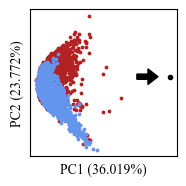

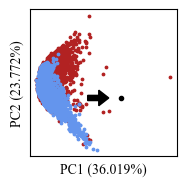

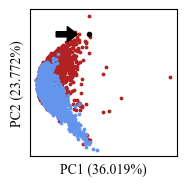

In [195]:
for N in ['LIKBIS','NEJGER','YEJLOR']:
    Ns = [j for i,j in zip(Synthetic['database ID'],Synthetic['smiles']) if i and N.lower() == i.lower()]
    print(Ns)
    Ns = [n for n,i in enumerate(Synthetic['database ID']) if i and N.lower() == i.lower()]
    fig, ax = plt.subplots(1,1,figsize=(5*cm, 5*cm))
    point_size = 3
    ax.set_xlabel('PC1 ('+str(round(pca.explained_variance_ratio_[0]*100,3))+'%)')
    ax.set_ylabel('PC2 ('+str(round(pca.explained_variance_ratio_[1]*100,3))+'%)')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.scatter(Synthetic['PC1'],Synthetic['PC2'],label='SC\n(n='+str(len(SN_pre))+')',color='firebrick',s=point_size)
    ax.scatter(Natural['PC1'],Natural['PC2'],label='NC\n(n='+str(len(NP_pre))+')',color='cornflowerblue',s=point_size)
    ax.scatter([Synthetic['PC1'][i] for i in Ns],[Synthetic['PC2'][i] for i in Ns],color='black',s=point_size*3)
    ax.arrow([Synthetic['PC1'][i] for i in Ns][0]-15,[Synthetic['PC2'][i] for i in Ns][0],5,0,width=1,color='black',shape='full',head_starts_at_zero=False)
    Xaxis = ax.get_xlim()
    Yaxis = ax.get_ylim()
    fig.tight_layout()
    fig.savefig('Publication Images/'+'Figure11-'+N+'.png',dpi=1000)

### Figure 12

['OCC1OC2OC3C(CO)OC(OC4C(CO)OC(OC5C(CNCCc6c[nH]cn6)OC(OC6C(CO)OC(OC7C(CO)OC(OC8C(CO)OC(OC1C(O)C2O)C(O)C8O)C(O)C7O)C(O)C6O)C(O)C5O)C(O)C4O)C(O)C3O']
['OC[C@H]1O[C@@H](NCCN(CCN[C@@H]2O[C@H](CO)[C@@H](O)[C@H](O)[C@H]2O)CCN[C@@H]2O[C@H](CO)[C@@H](O)[C@H](O)[C@H]2O)[C@H](O)[C@@H](O)[C@@H]1O']


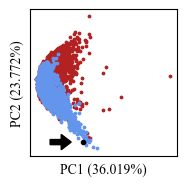

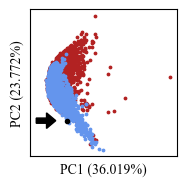

In [196]:
for N in ['TOCQAD','PACJIN']:
    Ns = [j for i,j in zip(Synthetic['database ID'],Synthetic['smiles']) if i and N.lower() == i.lower()]
    print(Ns)
    Ns = [n for n,i in enumerate(Synthetic['database ID']) if i and N.lower() == i.lower()]
    fig, ax = plt.subplots(1,1,figsize=(5*cm, 5*cm))
    point_size = 3
    ax.set_xlabel('PC1 ('+str(round(pca.explained_variance_ratio_[0]*100,3))+'%)')
    ax.set_ylabel('PC2 ('+str(round(pca.explained_variance_ratio_[1]*100,3))+'%)')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.scatter(Synthetic['PC1'],Synthetic['PC2'],label='SC\n(n='+str(len(SN_pre))+')',color='firebrick',s=point_size)
    ax.scatter(Natural['PC1'],Natural['PC2'],label='NC\n(n='+str(len(NP_pre))+')',color='cornflowerblue',s=point_size)
    ax.scatter([Synthetic['PC1'][i] for i in Ns],[Synthetic['PC2'][i] for i in Ns],color='black',s=point_size*3)
    ax.arrow([Synthetic['PC1'][i] for i in Ns][0]-15,[Synthetic['PC2'][i] for i in Ns][0],5,0,width=1,color='black',shape='full',head_starts_at_zero=False)
    Xaxis = ax.get_xlim()
    Yaxis = ax.get_ylim()
    fig.tight_layout()
    fig.savefig('Publication Images/'+'Figure12-'+N+'.png',dpi=1000)